In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [6]:
tb = pd.read_csv('/Users/jangjuyeong/Documents/메타코드(spyder)/금융데이터분석_강의자료_메타코드M/data/bootcamp_chapter3-1_data.csv')
tb

,customer_id,join_dt,approved_dt,transaction_amt
0,1,2019-04-02,2024-09-24 05:23:09,34.57
1,2,2019-04-03,NaN,NaN
2,3,2019-04-02,NaN,NaN
3,4,2019-04-02,2024-10-20 14:45:53,9.93
4,4,2019-04-02,2024-10-23 16:14:14,15.71
...,...,...,...,...
441949,64208,2019-04-03,2024-11-25 15:55:38,7.00
441950,64208,2019-04-03,2024-11-26 21:35:41,0.57
441951,64209,2019-04-03,2024-09-08 12:15:53,0.86
441952,64209,2019-04-03,2024-10-11 12:47:38,12.14


In [8]:
df = tb[tb.approved_dt.notnull()]
df['approved_dt'] = df['approved_dt'].apply(lambda x : datetime.strptime(x, '%Y-%m-%d %H:%M:%S'))

결제 월과 코호트 월 생성

In [9]:
df['transaction_week'] = df['approved_dt'].dt.to_period('W')
df['cohort_week'] = df.groupby('customer_id')['transaction_week'].transform('min')

In [11]:
#코호트 기간 계산
df['period'] = (df['transaction_week'] - df['cohort_week']).apply(lambda x: x.n)

In [12]:
#코호트 테이블 생성
cohort_table = df.groupby(['cohort_week', 'period'])['customer_id'].nunique().unstack(fill_value=0)

In [13]:
#상대적 비율 계산(최초 월 대비 유지율)
cohort_size = cohort_table.iloc[:,0]
retention_table = cohort_table.divide(cohort_size, axis=0)

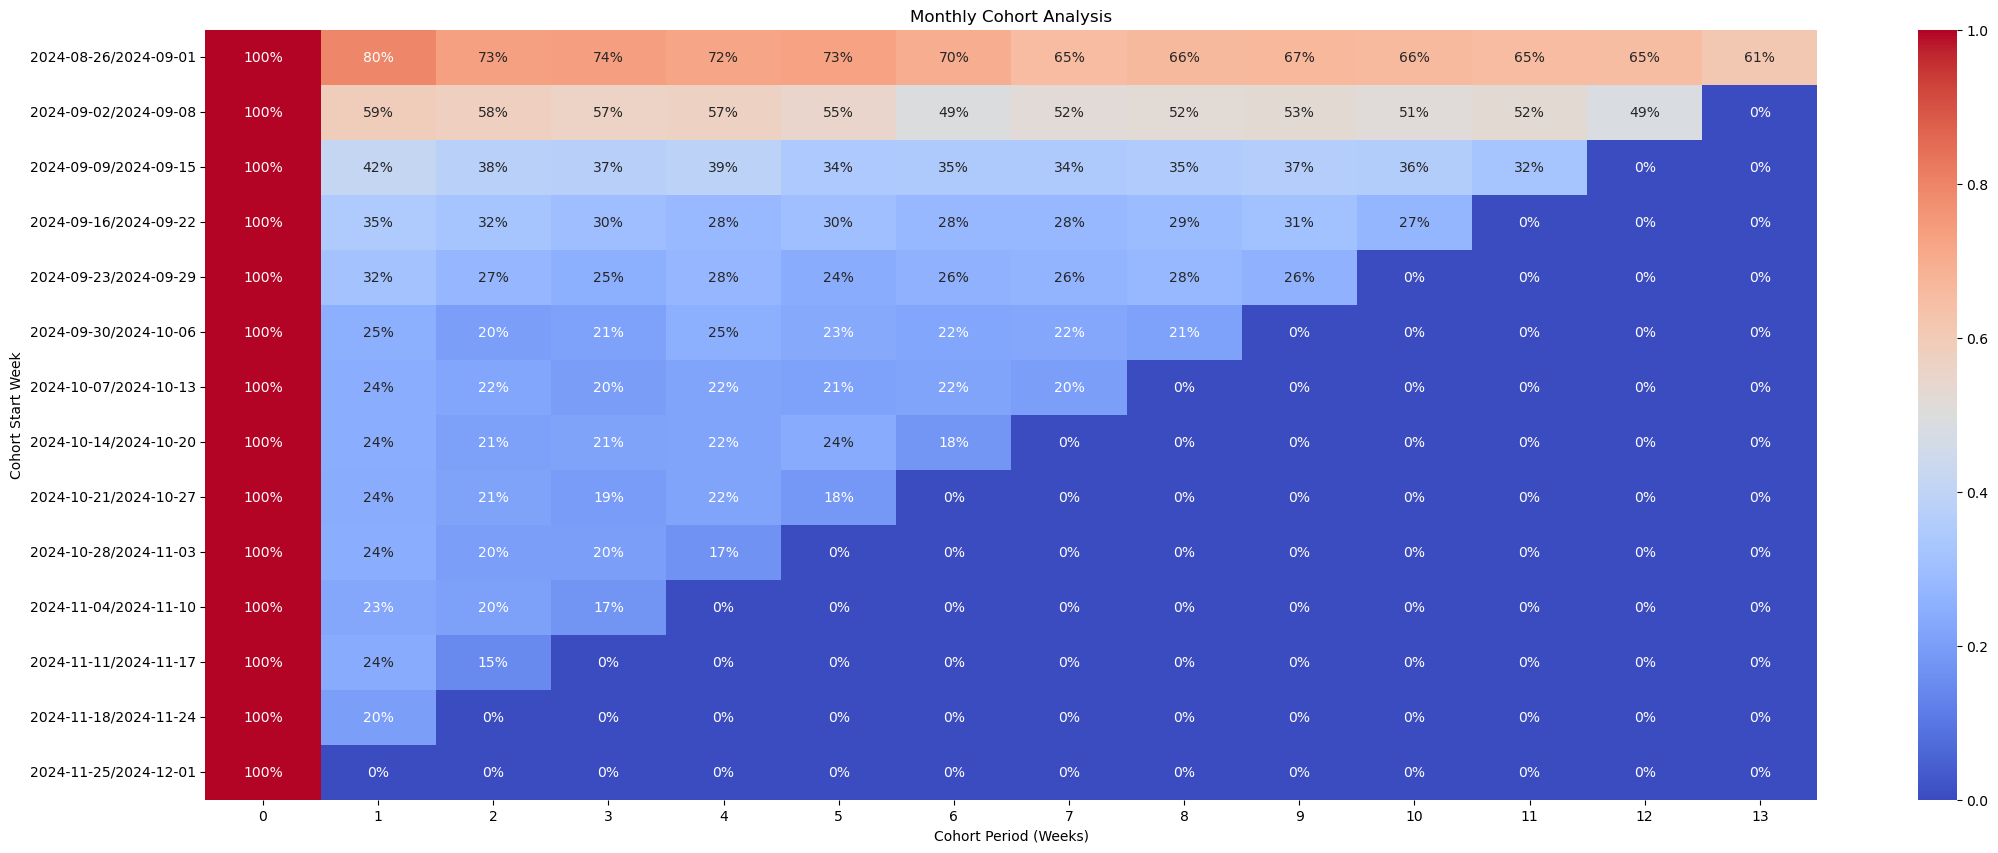

In [17]:
#시각화
plt.figure(figsize = (26,10))
sns.heatmap(retention_table, annot=True, fmt='.0%', cmap='coolwarm')
plt.title('Monthly Cohort Analysis')
plt.xlabel('Cohort Period (Weeks)')
plt.ylabel('Cohort Start Week')
plt.show()

Inflow와 리텐션 및 이탈률을 구하고 cc 계산하기

In [18]:
#주평균 획득(Acquisition) 유저 수 구하기
tb['join_dt'] = tb['join_dt'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d'))
tb['join_week'] = tb['join_dt'].dt.to_period('W')
inflow_tmp = tb.groupby('join_week').customer_id.nunique().reset_index()
inflow_tmp

,join_week,customer_id
0,2019-04-01/2019-04-07,30483
1,2019-04-08/2019-04-14,363
2,2019-04-15/2019-04-21,315
3,2019-04-22/2019-04-28,448
4,2019-04-29/2019-05-05,363
...,...,...
274,2024-07-01/2024-07-07,6
275,2024-07-08/2024-07-14,9
276,2024-07-15/2024-07-21,5
277,2024-07-22/2024-07-28,4


<Axes: >

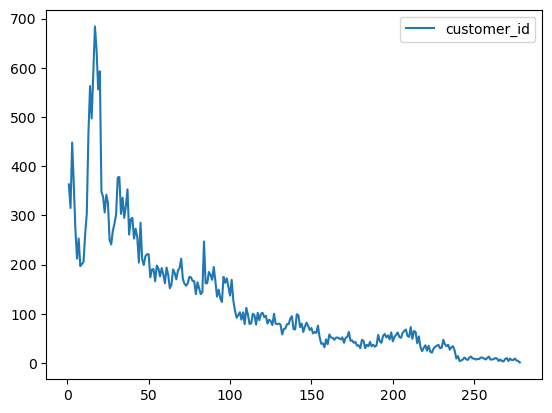

In [20]:
sns.lineplot(inflow_tmp.loc[1:, :])

In [21]:
inflow = inflow_tmp.customer_id.mean()

In [22]:
inflow

230.14336917562724

In [23]:
tmp = df.groupby('customer_id').approved_dt.min().reset_index()
tmp = tmp[tmp['approved_dt']<'2024-10-28']
tmp2 = df[df.customer_id.isin(tmp.customer_id.unique())]

retention_tmp = tmp2.groupby('period').customer_id.nunique() / tmp2.customer_id.nunique()
retention_tmp = retention_tmp.reset_index()


In [24]:
retention_tmp

,period,customer_id
0,0,1.000000
1,1,0.485160
2,2,0.455754
3,3,0.444893
4,4,0.450814
5,5,0.435444
6,6,0.400706
7,7,0.398118
8,8,0.392550
9,9,0.385885


<Axes: xlabel='period', ylabel='customer_id'>

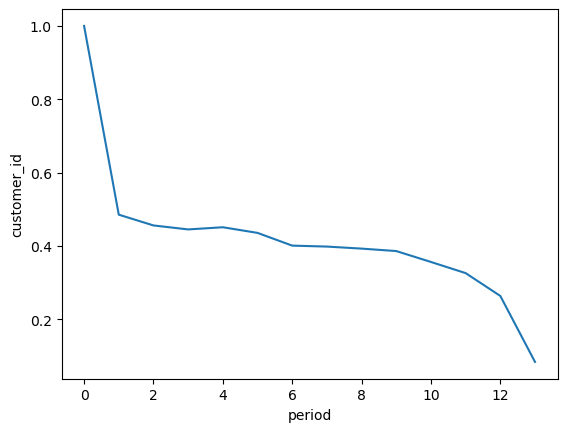

In [25]:
sns.lineplot(retention_tmp, x = 'period', y = 'customer_id')

매주 거래를 하는게 일반적이다.  
처음 거래를 하고 나갈 유저들은 이미 다 나가고 이후에는 평탄화되는 모습들이 나타난다.  
그러므로 retention을 첫 주로 잡아도 무방하다.

In [26]:
#Retention 구하기
retention = retention_tmp.loc[1][1]

#cc구하기
cc = inflow / (1-retention)

print('# of users acquire: {}'.format(inflow))
print('retention_rate: {}'.format(retention))
print('cc: {}'.format(cc))

# of users acquire: 230.14336917562724
retention_rate: 0.4851597725936091
cc: 447.019010800729


230명 가량의 inflow가 들어오는 것 확인  
retention은 한 주가 지나고 나면 48.5%가량 남는 것을 확인  
우리 제품의 한계 성장은 약 447명이 될 것으로 확인  